<a href="https://colab.research.google.com/github/ahnasiakg2234/Assignment4ML/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1 of Assignment 4 Build a CNN Model

In [ ]:
# Step 1 Data Preprocessing
# Loading, normalizing and splitting the dataset
#Loaded dataset using torchvision
# normalized values using tensor transform
# Split data into training and validation subsets


from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./Assignment4ML/data', train=True, download=True, transform=transform)

train_sub, val_sub = random_split(train_dataset, [50000, 10000])

train_loader = DataLoader(train_sub, batch_size=64, shuffle=True)
val_loader = DataLoader(val_sub, batch_size=64, shuffle=False)

In [ ]:
# Initial version of CNN model
#Created class to inherit cnn methods
import torch
import torch.nn as nn

class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()
        # first block allows for simple pattern search
        #uses 2 convolutional layers, and relu activation to allow for complexity
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            # helps model focus on important patterns and features
            nn.MaxPool2d(2)
        )
        # second block allows for more complex pattern search
        # increased filter count/depth
        #Pools again to reduce size
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1) #flattens data into a vector
        return self.fc(x) # classifies 10 categories
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Set up the model and hyperparameters
# use cross entropy to measure prediction error from actual labels
# use adam algo to minimize loss, small learning rate
model = DeepCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import torch.optim as optim
# Ready to train model, set number of times full dataset is gone through
#track training loss, validation loss, and accuracy for both to check for overfitting

epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()
 # evaluate the model previously trained and analysis output
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()

    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['train_acc'].append(train_correct / len(train_sub))
    history['val_acc'].append(val_correct / len(val_sub))

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")

Epoch [1/10] | Train Loss: 0.4002 | Val Loss: 0.3185 | Val Acc: 0.8823
Epoch [2/10] | Train Loss: 0.2890 | Val Loss: 0.2905 | Val Acc: 0.8980
Epoch [3/10] | Train Loss: 0.2431 | Val Loss: 0.2457 | Val Acc: 0.9123
Epoch [4/10] | Train Loss: 0.2122 | Val Loss: 0.2394 | Val Acc: 0.9141
Epoch [5/10] | Train Loss: 0.1909 | Val Loss: 0.2254 | Val Acc: 0.9174
Epoch [6/10] | Train Loss: 0.1696 | Val Loss: 0.2337 | Val Acc: 0.9138
Epoch [7/10] | Train Loss: 0.1539 | Val Loss: 0.2280 | Val Acc: 0.9174
Epoch [8/10] | Train Loss: 0.1385 | Val Loss: 0.2486 | Val Acc: 0.9122
Epoch [9/10] | Train Loss: 0.1259 | Val Loss: 0.2273 | Val Acc: 0.9202
Epoch [10/10] | Train Loss: 0.1124 | Val Loss: 0.2602 | Val Acc: 0.9136


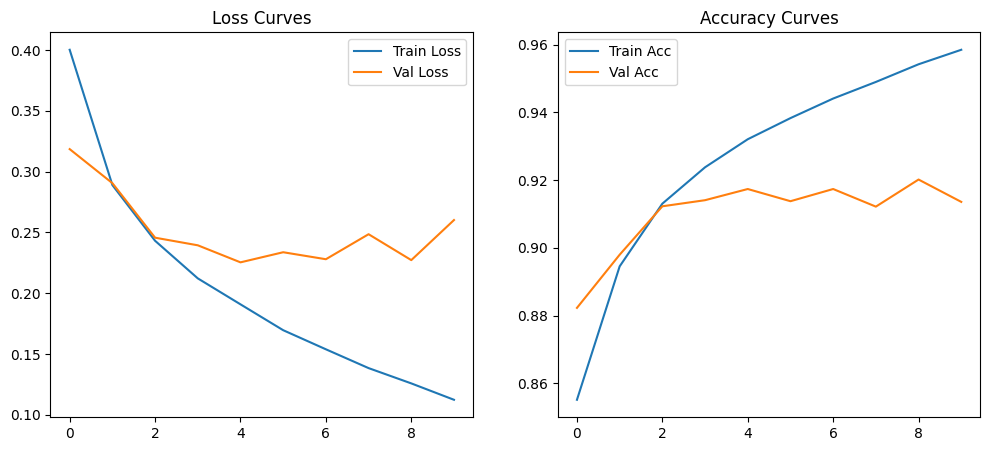

In [ ]:
#use matplotlib to plot the loss curves based on the epoch size
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plots Loss for both training and validation
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

# Plots Accuracy for both training and validation
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

plt.show()


Final Validation Accuracy: 0.9136


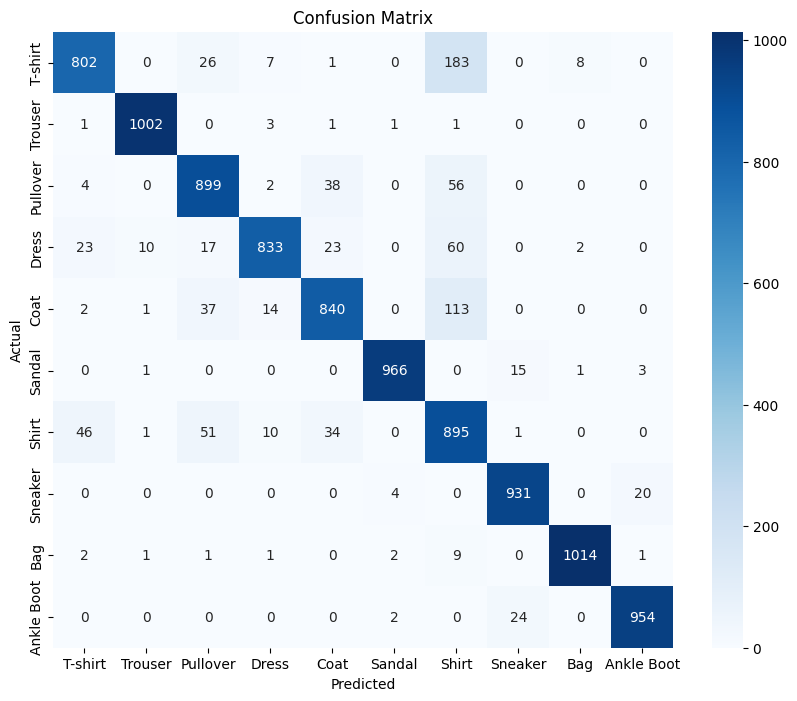

In [ ]:
# use scikit and seaborn to plot confusion matrix with heatmap
# provides further analysis of results
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Test Accuracy
test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\nFinal Validation Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Version 2 of the first CNN Model with improvements

In [ ]:
# After initial cnn model hit a ceiling, decided to add improvements
class DeepCNN2(nn.Module):
    def __init__(self):
        super(DeepCNN2, self).__init__()
        # Two conv layers before the first pool
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Higher filter count in the second block
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential (
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return self.fc(x)
device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = DeepCNN2().to(device2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

In [ ]:
epochs = 5
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    model2.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device2), labels.to(device2)

        optimizer.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()

    model2.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device2), labels.to(device2)
            outputs = model2(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()

    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['train_acc'].append(train_correct / len(train_sub))
    history['val_acc'].append(val_correct / len(val_sub))

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")

Epoch [1/5] | Train Loss: 0.4997 | Val Loss: 0.2989 | Val Acc: 0.8883
Epoch [2/5] | Train Loss: 0.3325 | Val Loss: 0.2558 | Val Acc: 0.9021
Epoch [3/5] | Train Loss: 0.2878 | Val Loss: 0.2458 | Val Acc: 0.9079
Epoch [4/5] | Train Loss: 0.2618 | Val Loss: 0.2240 | Val Acc: 0.9136
Epoch [5/5] | Train Loss: 0.2373 | Val Loss: 0.2125 | Val Acc: 0.9203


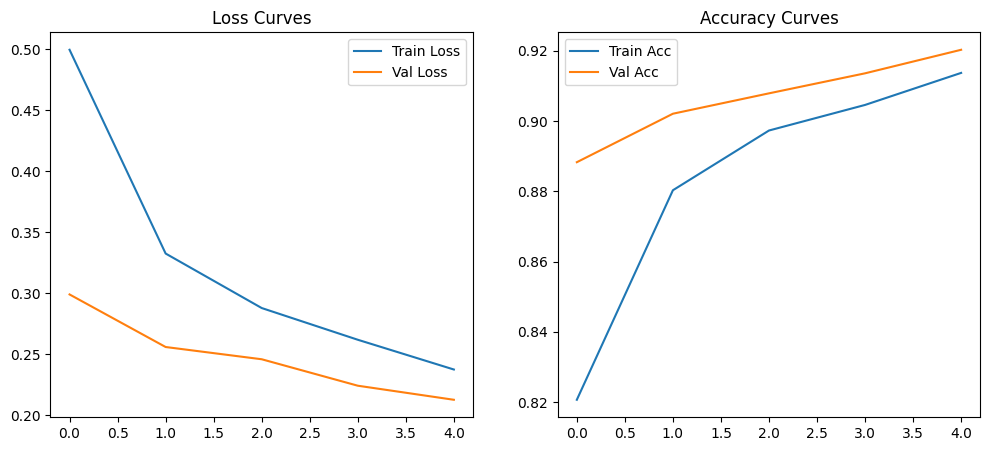

In [ ]:
# plot the loss and accuracy curves by the number of epochs
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

plt.show()


Final Validation Accuracy: 0.9203


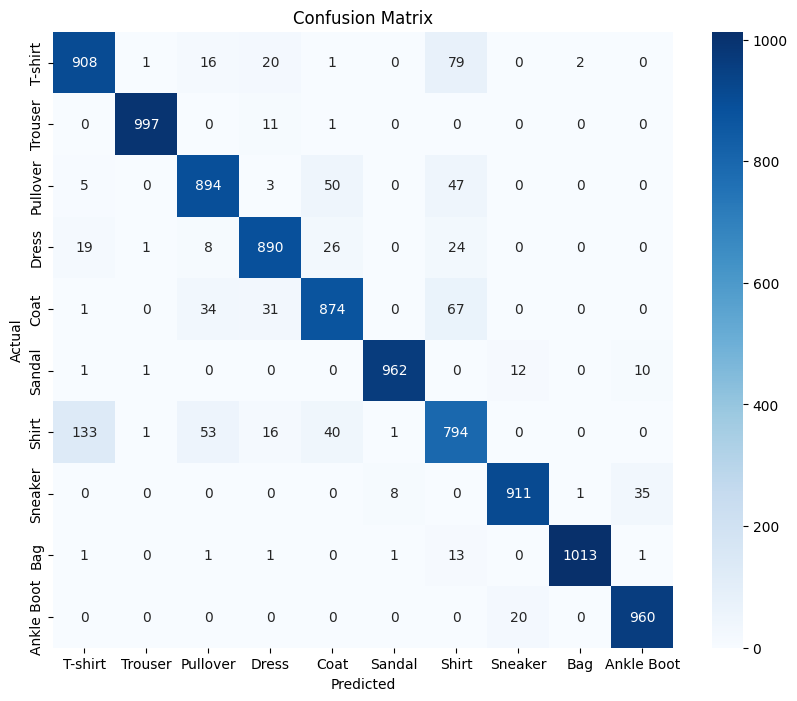

In [ ]:
#version 2
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model2.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device2), labels.to(device2)
        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\nFinal Validation Accuracy: {test_accuracy:.4f}")

classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Part 2 of Assignment 4 LLM Fine tuning using GPT-2

In [7]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import Dataset
import pandas as pd

#Loading jokes from the data file
df = pd.read_csv('data.csv')
data = df['Joke'].tolist()

#Initialize the tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
#Set boundaries of where the jokes start and end for clarity
formatted_jokes = [f"{tokenizer.bos_token} {joke} {tokenizer.eos_token}" for joke in data]

joke_dataset = Dataset.from_dict({"text": formatted_jokes})
# convert strings into numeric tensors
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128, padding="max_length")
#Tokenize the dataset
tokenized_dataset = joke_dataset.map(tokenize_function, batched=True)
#Load the Model for text generation
model = GPT2LMHeadModel.from_pretrained("gpt2")
#training "rules" to fine tune
training_args = TrainingArguments(
    output_dir="./joke_gpt2_model",
    max_steps=2000,
    num_train_epochs=10,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=3e-5,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,
    save_strategy="no",
    report_to="none"
)
#execute training using collator so model learns to predict

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    train_dataset=tokenized_dataset,
)

print("Starting Fine-Tuning...")
trainer.train()
#Exporting the model
trainer.save_model("./joke_gpt2_model")
tokenizer.save_pretrained("./joke_gpt2_model")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Starting Fine-Tuning...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,4.084962
200,3.826755
300,3.713033
400,3.706805
500,3.327360
600,3.210876
700,3.282191
800,3.195519
900,3.009013
1000,2.927386


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./joke_gpt2_model/tokenizer_config.json', './joke_gpt2_model/tokenizer.json')

In [14]:
import torch

model_path = "./joke_gpt2_model"
model = GPT2LMHeadModel.from_pretrained(model_path)
tokenizer = GPT2Tokenizer.from_pretrained(model_path)

model.eval()
#initializes the seeds from the data and at random
seeds = [
    "What did the",
    "Why did the",
    "How do you",
    "What do you "
]
# function that generates joke based on seeds
def generate_joke(seed_text):
    input_text = f"{tokenizer.bos_token} {seed_text}"
    inputs = tokenizer.encode(input_text, return_tensors="pt")

    outputs = model.generate(
        inputs,
        max_length=20,
        num_return_sequences=1,
        no_repeat_ngram_size=2, # Prevents the model from getting stuck in a loop
        do_sample=True,         # Enables randomness
        top_k=60,               # Limits vocabulary to top 50 most likely next words
        top_p=0.95,             # Nucleus sampling for diversity
        temperature=0.7,        # Higher = more creative/chaotic, Lower = more predictable
        pad_token_id=tokenizer.eos_token_id
    )

    joke = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return joke
#prints some jokes after model generates
for seed in seeds:
    generated = generate_joke(seed)
    print(f"Seed: {seed} : {generated}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Seed: What did the :  What did the horse say when he got his wish? "Thanks, dear." ~~Skip
Seed: Why did the :  Why did the chicken cross the playground? To get to the other slide !!!! !!! 
Seed: How do you :  How do you make a chicken laugh? You put a little beef in it.  You
Seed: What do you  :  What do you iced tea with? erythritol ersatz. ~~
